<a href="https://colab.research.google.com/github/Kadidjah/Engenharia_de_Prompt_e_Aplicacao_AI/blob/main/Aula08_Automacao_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Aula 08_Automação com Inteligência
Nome: Kadidja Valéria


In [6]:
# Este script Python simples verifica a temperatura de um sistema.
# Se a temperatura for maior que 30 graus Celsius, um alerta de aquecimento é exibido.

try:
    # Solicita ao usuário que digite a temperatura atual do sistema
    temperatura_str = input("Digite a temperatura atual do sistema (em graus Celsius): ")

    # Converte a entrada do usuário (que é uma string) para um número de ponto flutuante (float)
    temperatura = float(temperatura_str)

    # Verifica se a temperatura é maior que 30 graus Celsius
    if temperatura > 30:
        # Se for maior, imprime um alerta de aquecimento
        print("ALERTA DE AQUECIMENTO! Temperatura atual: " + str(temperatura) + "°C. Recomenda-se verificar o sistema.")
    else:
        # Caso contrário (temperatura <= 30), imprime que a temperatura está normal
        print("Temperatura do sistema: " + str(temperatura) + "°C. Tudo parece normal.")

# Captura o erro se o usuário digitar algo que não pode ser convertido em um número
except ValueError:
    # Informa ao usuário que a entrada foi inválida
    print("Entrada inválida. Por favor, digite um número para a temperatura.")

Digite a temperatura atual do sistema (em graus Celsius): 56
ALERTA DE AQUECIMENTO! Temperatura atual: 56.0°C. Recomenda-se verificar o sistema.


Criar um programa que organize arquivos bagunçados em pastas automaticamente, baseando-se apenas na extensão do arquivo (ex. .pdf, .jpg) Use biblioteca os ou shutil.

In [5]:
import os
import shutil

def organizar_arquivos_por_extensao(diretorio_origem):
    """
    Organiza arquivos em pastas com base em suas extensões.

    Args:
        diretorio_origem (str): O caminho para o diretório onde os arquivos estão bagunçados.
    """
    if not os.path.isdir(diretorio_origem):
        print(f"Erro: O diretório de origem '{diretorio_origem}' não existe.")
        return

    print(f"Organizando arquivos em: {diretorio_origem}")

    # Dicionário para mapear extensões a nomes de pastas em português
    extensao_para_pasta = {
        'pdf': 'Documentos PDF',
        'doc': 'Documentos Word',
        'docx': 'Documentos Word',
        'xls': 'Planilhas Excel',
        'xlsx': 'Planilhas Excel',
        'ppt': 'Apresentações PowerPoint',
        'pptx': 'Apresentações PowerPoint',
        'jpg': 'Imagens',
        'jpeg': 'Imagens',
        'png': 'Imagens',
        'gif': 'Imagens',
        'bmp': 'Imagens',
        'txt': 'Arquivos de Texto',
        'zip': 'Arquivos Compactados',
        'rar': 'Arquivos Compactados',
        '7z': 'Arquivos Compactados',
        'mp3': 'Áudios',
        'wav': 'Áudios',
        'mp4': 'Vídeos',
        'avi': 'Vídeos',
        'mkv': 'Vídeos',
        'py': 'Scripts Python',
        'js': 'Scripts JavaScript',
        'html': 'Páginas Web',
        'css': 'Folhas de Estilo CSS'
    }

    for nome_arquivo in os.listdir(diretorio_origem):
        caminho_completo_origem = os.path.join(diretorio_origem, nome_arquivo)

        # Ignora diretórios e garante que apenas arquivos são processados
        if os.path.isfile(caminho_completo_origem):
            # Obtém o nome base e a extensão do arquivo
            _, extensao = os.path.splitext(nome_arquivo)

            # Remove o ponto da extensão e a converte para minúsculas
            extensao = extensao.lstrip('.').lower()

            if extensao:
                # Obtém o nome da pasta em português, ou um nome genérico se não estiver mapeado
                nome_pasta = extensao_para_pasta.get(extensao, f'{extensao.upper()}_Arquivos')
                diretorio_destino = os.path.join(diretorio_origem, nome_pasta)

                # Cria o diretório de destino se ele não existir
                os.makedirs(diretorio_destino, exist_ok=True)

                caminho_completo_destino = os.path.join(diretorio_destino, nome_arquivo)

                try:
                    shutil.move(caminho_completo_origem, caminho_completo_destino)
                    print(f"Movido '{nome_arquivo}' para '{diretorio_destino}'")
                except shutil.Error as e:
                    print(f"Erro ao mover '{nome_arquivo}': {e}")
                except Exception as e:
                    print(f"Ocorreu um erro inesperado ao mover '{nome_arquivo}': {e}")
            else:
                print(f"Ignorado '{nome_arquivo}': sem extensão conhecida.")

    print("Organização de arquivos concluída!")

# --- Como usar o programa ---
# 1. Altere o valor da variável 'diretorio_para_organizar' para o caminho da sua pasta.
#    Exemplos: './minha_pasta_baguncada' ou '/caminho/para/seus/arquivos'
# 2. Execute esta célula.

# Defina o diretório que você deseja organizar
# ATENÇÃO: Certifique-se de que este é o diretório correto, pois o script irá mover arquivos.
# Se for para organizar o diretório atual onde o notebook está rodando, use os.getcwd()

diretorio_para_organizar = os.getcwd() # Ou './meus_arquivos_baguncados' ou 'arquivos_para_organizar'

# Cria algumas pastas de exemplo e arquivos para teste (opcional)
# Remova ou comente este bloco se você já tem arquivos para testar.
if diretorio_para_organizar == os.getcwd():
    print("Criando arquivos de teste no diretório atual...")
    test_dir = os.path.join(diretorio_para_organizar, 'test_files_to_organize')
    os.makedirs(test_dir, exist_ok=True)
    with open(os.path.join(test_dir, 'documento1.pdf'), 'w') as f: f.write('dummy')
    with open(os.path.join(test_dir, 'foto1.jpg'), 'w') as f: f.write('dummy')
    with open(os.path.join(test_dir, 'planilha.xlsx'), 'w') as f: f.write('dummy')
    with open(os.path.join(test_dir, 'script.py'), 'w') as f: f.write('dummy')
    with open(os.path.join(test_dir, 'arquivo_sem_extensao'), 'w') as f: f.write('dummy')
    with open(os.path.join(test_dir, 'outro_documento.PDF'), 'w') as f: f.write('dummy')
    diretorio_para_organizar = test_dir # Altera para o diretório de teste


# Chama a função para organizar os arquivos
organizar_arquivos_por_extensao(diretorio_para_organizar)

Criando arquivos de teste no diretório atual...
Organizando arquivos em: /content/test_files_to_organize
Movido 'outro_documento.PDF' para '/content/test_files_to_organize/Documentos PDF'
Movido 'documento1.pdf' para '/content/test_files_to_organize/Documentos PDF'
Ignorado 'arquivo_sem_extensao': sem extensão conhecida.
Movido 'script.py' para '/content/test_files_to_organize/Scripts Python'
Movido 'foto1.jpg' para '/content/test_files_to_organize/Imagens'
Movido 'planilha.xlsx' para '/content/test_files_to_organize/Planilhas Excel'
Organização de arquivos concluída!


Consulta Simples a APIs Deenvolver um script que consulte uma API pública VIACEP e retorne as informações de endereço formatadas de maneira legíve. Inclua tratamento de exceções try/except.

In [8]:
import requests

def consultar_cep(cep):
    """
    Consulta a API pública VIACEP para obter informações de endereço.
    Args:
        cep (str): O número do CEP a ser consultado (apenas dígitos).
    Returns:
        dict or None: Um dicionário com os dados do endereço formatados, ou None se ocorrer um erro.
    """
    # Remove qualquer caractere não numérico do CEP
    cep = ''.join(filter(str.isdigit, cep))

    if len(cep) != 8:
        print("Erro: O CEP deve conter exatamente 8 dígitos.")
        return None

    url = f"https://viacep.com.br/ws/{cep}/json/"

    try:
        # Faz a requisição HTTP para a API
        response = requests.get(url)
        response.raise_for_status()  # Lança uma exceção para códigos de status HTTP de erro (4xx ou 5xx)

        data = response.json()

        # Verifica se a API retornou um erro (ex: CEP inválido)
        if 'erro' in data and data['erro']:
            print(f"Erro: CEP '{cep}' não encontrado ou inválido.")
            return None

        # Formata as informações de endereço
        endereco_formatado = {
            "CEP": data.get('cep'),
            "Logradouro": data.get('logradouro'),
            "Complemento": data.get('complemento'),
            "Bairro": data.get('bairro'),
            "Cidade": data.get('localidade'),
            "Estado": data.get('uf'),
            "IBGE": data.get('ibge'),
            "GIA": data.get('gia'),
            "DDD": data.get('ddd'),
            "SIAFI": data.get('siafi')
        }
        return endereco_formatado

    except requests.exceptions.HTTPError as http_err:
        print(f"Erro HTTP ao consultar o CEP {cep}: {http_err}")
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Erro de conexão ao consultar o CEP {cep}: {conn_err}. Verifique sua internet.")
    except requests.exceptions.Timeout as timeout_err:
        print(f"Erro de tempo limite ao consultar o CEP {cep}: {timeout_err}")
    except requests.exceptions.RequestException as req_err:
        print(f"Ocorreu um erro inesperado na requisição para o CEP {cep}: {req_err}")
    except ValueError as val_err:
        print(f"Erro ao processar a resposta JSON para o CEP {cep}: {val_err}")
    except Exception as e:
        print(f"Ocorreu um erro desconhecido ao consultar o CEP {cep}: {e}")

    return None

# --- Exemplo de uso ---

# Solicita ao usuário que insira um CEP
cep_digitado = input("Digite o CEP (apenas números): ")

# Consulta o CEP
endereco = consultar_cep(cep_digitado)

# Exibe o resultado de forma legível
if endereco:
    print("\n--- Informações do Endereço ---")
    for chave, valor in endereco.items():
        if valor: # Exibe apenas campos com valor preenchido
            print(f"{chave}: {valor}")
else:
    print("Não foi possível obter informações para o CEP fornecido.")

Digite o CEP (apenas números): 70737030

--- Informações do Endereço ---
CEP: 70737-030
Logradouro: Quadra SQN 305 Bloco C
Bairro: Asa Norte
Cidade: Brasília
Estado: DF
IBGE: 5300108
DDD: 61
SIAFI: 9701


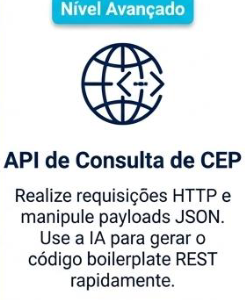